# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.portfolio as portfolio_module
import model.analysis.profit as profit_analysis
import model.data.loader as loader

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(portfolio_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.MortalityTable()

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest
)

# Portfolio Setup

In [5]:
portfolio = loader.load_portfolio_csv(
    "../data/sample_portfolio.csv"
)

portfolio

# Portfolio Inspection

In [6]:
len(portfolio.policies)

250

In [7]:
portfolio.policies[0]

Policy(age=60, term=12, sum_assured=25000.0, premium=291.0, weight=63)

# Portfolio Valuation

In [8]:
portfolio_result = portfolio.value(
    assumptions,
    return_breakdown=True
)

portfolio_result

PortfolioResult(policies=250, net_value=21588738.29)

# Portfolio DataFrame

In [9]:
portfolio_df = profit_analysis.build_profit_dataframe(
    portfolio_result
)

portfolio_df.head()

,t,age,discount_factor,expected_premium,expected_claim,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow
0,0,60,1.000000,1.000128e+08,4.426517e+07,5.574762e+07,1.000128e+08,4.426517e+07,5.574762e+07,5.574762e+07,5.574762e+07
1,1,61,0.970874,9.962687e+07,4.752844e+07,5.209843e+07,9.672512e+07,4.614411e+07,5.058100e+07,1.063286e+08,1.078460e+08
2,2,62,0.942596,9.921243e+07,5.099603e+07,4.821640e+07,9.351723e+07,4.806865e+07,4.544858e+07,1.517772e+08,1.560625e+08
3,3,63,0.915142,9.876768e+07,5.467478e+07,4.409290e+07,9.038642e+07,5.003517e+07,4.035125e+07,1.921284e+08,2.001553e+08
4,4,64,0.888487,9.829076e+07,5.857072e+07,3.972005e+07,8.733007e+07,5.203932e+07,3.529075e+07,2.274192e+08,2.398754e+08


# Profit Signature

In [10]:
portfolio_signature = profit_analysis.add_profit_signature(
    portfolio_df
)

portfolio_signature.head()

,t,age,discount_factor,expected_premium,expected_claim,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow,profit_pct
0,0,60,1.000000,1.000128e+08,4.426517e+07,5.574762e+07,1.000128e+08,4.426517e+07,5.574762e+07,5.574762e+07,5.574762e+07,2.582255
1,1,61,0.970874,9.962687e+07,4.752844e+07,5.209843e+07,9.672512e+07,4.614411e+07,5.058100e+07,1.063286e+08,1.078460e+08,2.342935
2,2,62,0.942596,9.921243e+07,5.099603e+07,4.821640e+07,9.351723e+07,4.806865e+07,4.544858e+07,1.517772e+08,1.560625e+08,2.105199
3,3,63,0.915142,9.876768e+07,5.467478e+07,4.409290e+07,9.038642e+07,5.003517e+07,4.035125e+07,1.921284e+08,2.001553e+08,1.869088
4,4,64,0.888487,9.829076e+07,5.857072e+07,3.972005e+07,8.733007e+07,5.203932e+07,3.529075e+07,2.274192e+08,2.398754e+08,1.634683


# Summary Metrics

In [11]:
profit_analysis.summary_metrics(portfolio_df)

{'total_pv_profit': np.float64(21588738.293868706),
 'total_cash_profit': np.float64(-285034004.5425093),
 'peak_profit_year': np.int64(0)}

# Visualisations

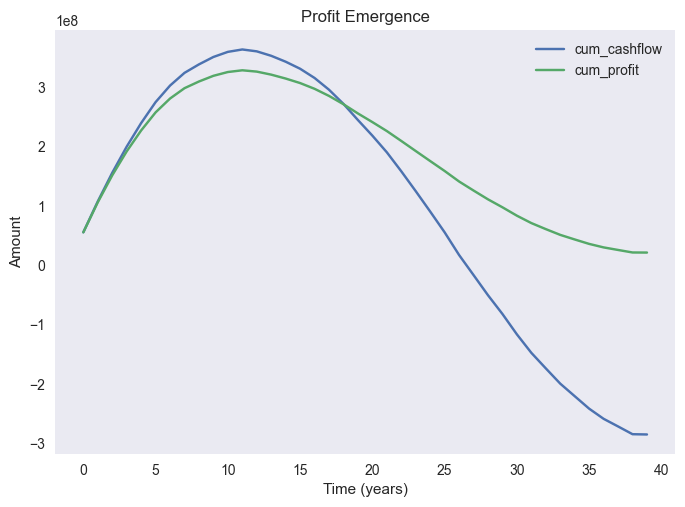

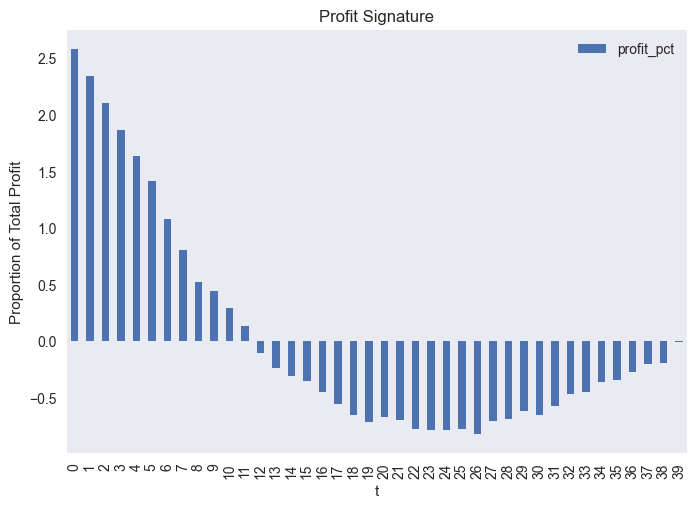

In [12]:
# Profit Emergence

portfolio_df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

portfolio_signature.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()